### `Import Dependencies`

In [1]:
import os, re, math, tqdm
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from ultralytics import YOLO
from flask import Flask, Response
from gfpgan import GFPGANer

### `STEP 1: PADDING`

In [ ]:
VIDEO_PATH = "input/after_lunch_1.mp4"
MODEL_PERSON = "weights/yolo11n.pt"
MODEL_FACE = "weights/yolov12n-face.pt"
TRACKER_YAML = "botsort.yaml"   # file cấu hình tracker YOLO
FACE_DIR = "face_padding"
os.makedirs(FACE_DIR, exist_ok=True)

PADDING = 0.25
PADDING_TOP = 0.4

In [ ]:
app = Flask(__name__)
person_model = YOLO(MODEL_PERSON)
face_model = YOLO(MODEL_FACE)
cap = cv2.VideoCapture(VIDEO_PATH)

In [ ]:
def generate_frames():
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        person_results = person_model.track(frame, conf=0.7, persist=True, verbose=False)
        annotated = frame.copy()
        for box in person_results[0].boxes:
            if box.id is None:
                continue
            tid = int(box.id.item())
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            person_crop = frame[y1:y2, x1:x2]
            if person_crop.size == 0:
                continue

            # Dò mặt trong vùng người
            face_results = face_model.predict(person_crop, conf=0.75, verbose=False)
            for fbox in face_results[0].boxes:
                fx1, fy1, fx2, fy2 = map(int, fbox.xyxy[0])
                gx1, gy1, gx2, gy2 = x1 + fx1, y1 + fy1, x1 + fx2, y1 + fy2
                bw, bh = gx2 - gx1, gy2 - gy1
                gx1 = max(0, int(gx1 - bw * PADDING))
                gy1 = max(0, int(gy1 - bh * PADDING_TOP))
                gx2 = min(frame.shape[1], int(gx2 + bw * PADDING))
                gy2 = min(frame.shape[0], int(gy2 + bh * PADDING))

                face_crop = frame[gy1:gy2, gx1:gx2]
                if face_crop.size == 0:
                    continue
                color = (0, 255, 255)
                cv2.rectangle(annotated, (gx1, gy1), (gx2, gy2), color, 2)
                cv2.putText(
                    annotated, f"ID {tid}",
                    (gx1, gy1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA
                )
                frame_id = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
                if frame_id % 10 == 0:
                    file_name = f"face_id{tid}_{frame_id}.jpg"
                    cv2.imwrite(os.path.join(FACE_DIR, file_name), face_crop)
        _, buffer = cv2.imencode(".jpg", annotated)
        yield (b'--frame\r\nContent-Type: image/jpeg\r\n\r\n' + buffer.tobytes() + b'\r\n')


In [ ]:
@app.route("/")
def video_feed():
    return Response(generate_frames(),
                    mimetype="multipart/x-mixed-replace; boundary=frame")


if __name__ == "__main__":
    app.run(host="localhost", port=1909, debug=False)

### `Comparing between with and without PADDING`

In [ ]:
FIRST_DIR = "face"
SECOND_DIR = "face_padding"
NUM_SHOW_IDS = 20

In [3]:
def parse_filename(filename):
    match = re.search(r"id(\d+)_(\d+)", filename)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

def group_by_id(directory):
    groups = defaultdict(list)
    for f in sorted(os.listdir(directory)):
        tid, frame_id = parse_filename(f)
        if tid is not None:
            groups[tid].append((frame_id, f))
    # sắp xếp frame theo thứ tự tăng dần
    for tid in groups:
        groups[tid].sort(key=lambda x: x[0])
    return groups

In [ ]:
groups_no = group_by_id(FIRST_DIR)
groups_pad = group_by_id(SECOND_DIR)

Thu muc face co 114 anh
Thu muc face_padding co 114 anh


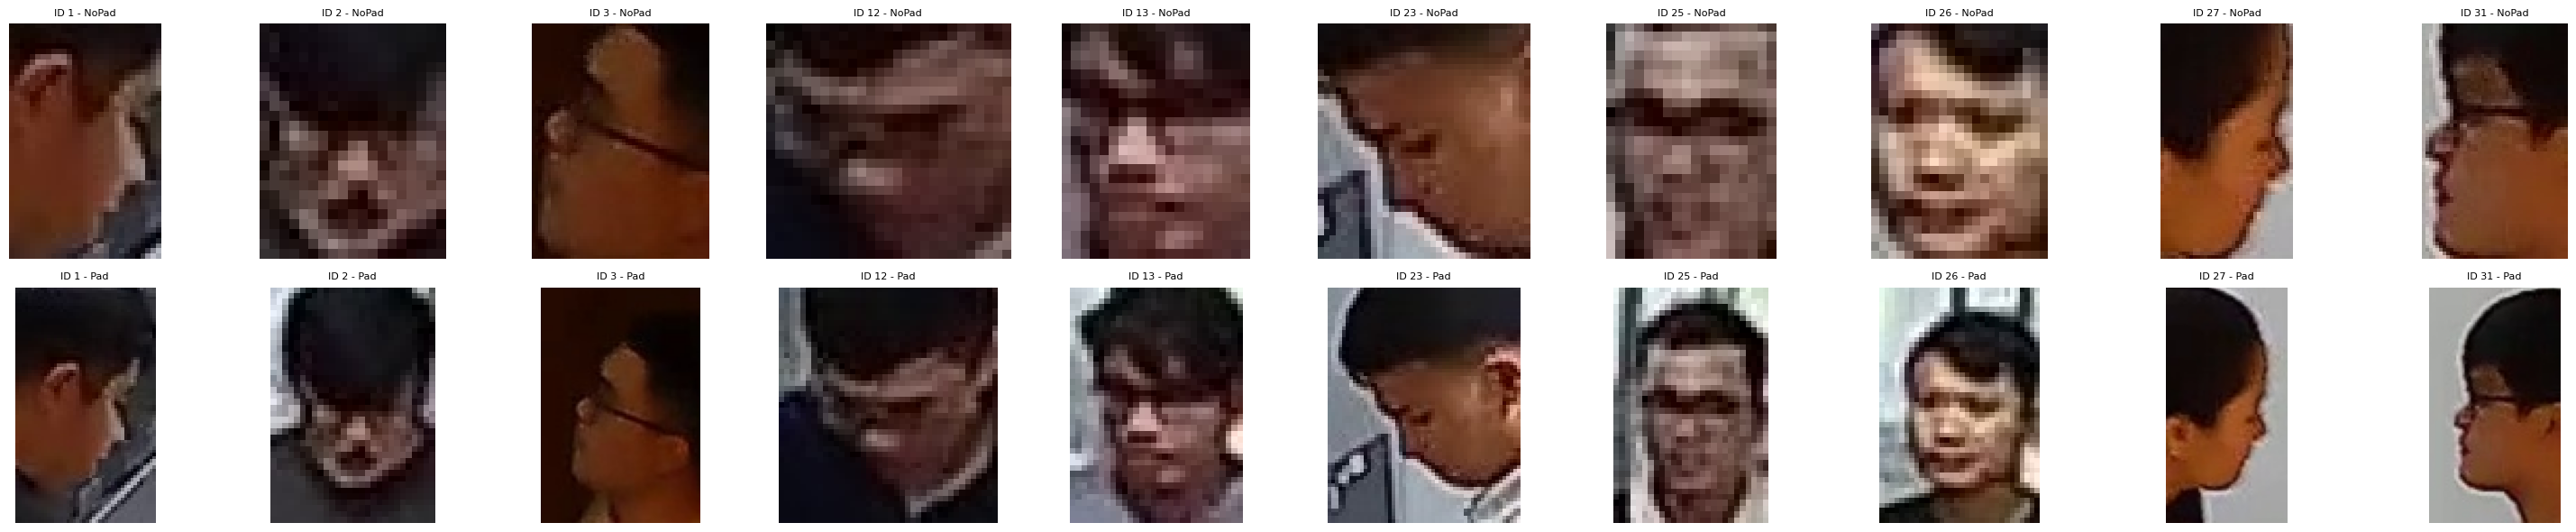

In [14]:
common_ids = sorted(set(groups_no.keys()) & set(groups_pad.keys()))
if not common_ids:
    print("Không tìm thấy ID trùng trong hai thư mục.")
else:
    print(f"Thu muc face co {len(os.listdir(FIRST_DIR))} anh")
    print(f"Thu muc face_padding co {len(os.listdir(SECOND_DIR))} anh")
    selected_ids = common_ids[:NUM_SHOW_IDS]
    plt.figure(figsize=(3 * len(selected_ids), 6))

    for idx, tid in enumerate(selected_ids):
        file_no = groups_no[tid][0][1]
        file_pad = groups_pad[tid][0][1]

        img_no = cv2.imread(os.path.join(FIRST_DIR, file_no))
        img_pad = cv2.imread(os.path.join(SECOND_DIR, file_pad))
        if img_no is None or img_pad is None:
            continue

        plt.subplot(2, len(selected_ids), idx + 1)
        plt.imshow(cv2.cvtColor(img_no, cv2.COLOR_BGR2RGB))
        plt.title(f"ID {tid} - NoPad", fontsize=8)
        plt.axis("off")

        plt.subplot(2, len(selected_ids), len(selected_ids) + idx + 1)
        plt.imshow(cv2.cvtColor(img_pad, cv2.COLOR_BGR2RGB))
        plt.title(f"ID {tid} - Pad", fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### `STEP 2: APPLY ROI`

In [ ]:
IN = "input/after_lunch_1.mp4"
OUT = "face_padding_roi"
MODEL_PERSON = "weights/yolo11n.pt"
MODEL_FACE = "weights/yolov12n-face.pt"
PADDING = 0.25
PADDING_TOP = 0.4
ROI_P = np.array([(935,463),(1210,509),(1507,1052),(789,1069)], np.int32)

os.makedirs(OUT, exist_ok = True)
cap = cv2.VideoCapture(IN)
person_model = YOLO(MODEL_PERSON)
face_model = YOLO(MODEL_FACE)
app = Flask(__name__)

def generate_frames():
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        overlay = frame.copy()
        cv2.polylines(overlay, [ROI_P], isClosed=True, color = (0,255,255), thickness = 2)
        cv2.fillPoly(overlay, [ROI_P], color = (0,255,255,40))
        alpha = 0.25
        annotated = cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0)
        person_result = person_model.track(frame, conf=0.7, persist = True, verbose = False)
        for box in person_result[0].boxes:
            if box.id is None:
                continue
            tid = int(box.id.item())
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cx, cy = int((x1+x2)/2), int(y2)
            inside = cv2.pointPolygonTest(ROI_P, (cx, cy), False)
            color_person = (0,255,0) if inside >= 0 else (0,0,255)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color_person, 2)
            cv2.putText(annotated, f"ID {tid}", (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_person, 2, cv2.LINE_AA)
            
            if inside < 0:
                continue

            person_crop = frame[y1:y2, x1:x2]
            if person_crop.size == 0:
                continue
            face_result = face_model.predict(person_crop, conf = 0.75, verbose = False)
            for fbox in face_result[0].boxes:
                fx1, fy1, fx2, fy2 = map(int, fbox.xyxy[0])
                gx1, gy1, gx2, gy2 = x1+fx1, y1+fy1, x1+fx2, y1+fy2
                bw, bh = gx2-gx1, gy2-gy1
                gx1 = max(0, int(gx1 - bw*PADDING))
                gy1 = max(0, int(gy1 - bh*PADDING_TOP))
                gx2 = min(frame.shape[1], int(gx2 + bw*PADDING))
                gy2 = min(frame.shape[0], int(gy2 + bh*PADDING))
                face_crop = frame[gy1:gy2, gx1:gx2]
                if face_crop.size == 0:
                    continue
                cv2.rectangle(annotated, (gx1,gy1), (gx2,gy2), (0,255,255), 2)
                frame_id = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
                if frame_id % 10 == 0:
                    file_name = f"face_id{tid}_{frame_id}.jpg"
                    cv2.imwrite(os.path.join(OUT, file_name), face_crop)
        _, buffer = cv2.imencode(".jpg", annotated)
        frame_bytes = buffer.tobytes()
        yield(b'--frame\r\n'
              b'Content-Type: image/jpeg\r\n\r\n' + frame_bytes + b'\r\n')
        
@app.route("/")
def video_feed():
    return Response(generate_frames(), mimetype = 'multipart/x-mixed-replace; boundary=frame')

if __name__== "__main__":
    app.run(host = 'localhost', port = 1909, debug =False)

In [28]:
THIRD_DIR = "face_padding_roi"
IMAGES_PER_ROW = 10

In [29]:
# Nhom anh theo id
groups_roi = defaultdict(list)
pattern = re.compile(r"face_id(\d+)_")

for file in sorted(os.listdir(THIRD_DIR)):
    match = pattern.search(file)
    if match:
        tid = int(match.group(1))
        groups_roi[tid].append(file)

Tìm thấy 15 ID trong thư mục face_padding_roi


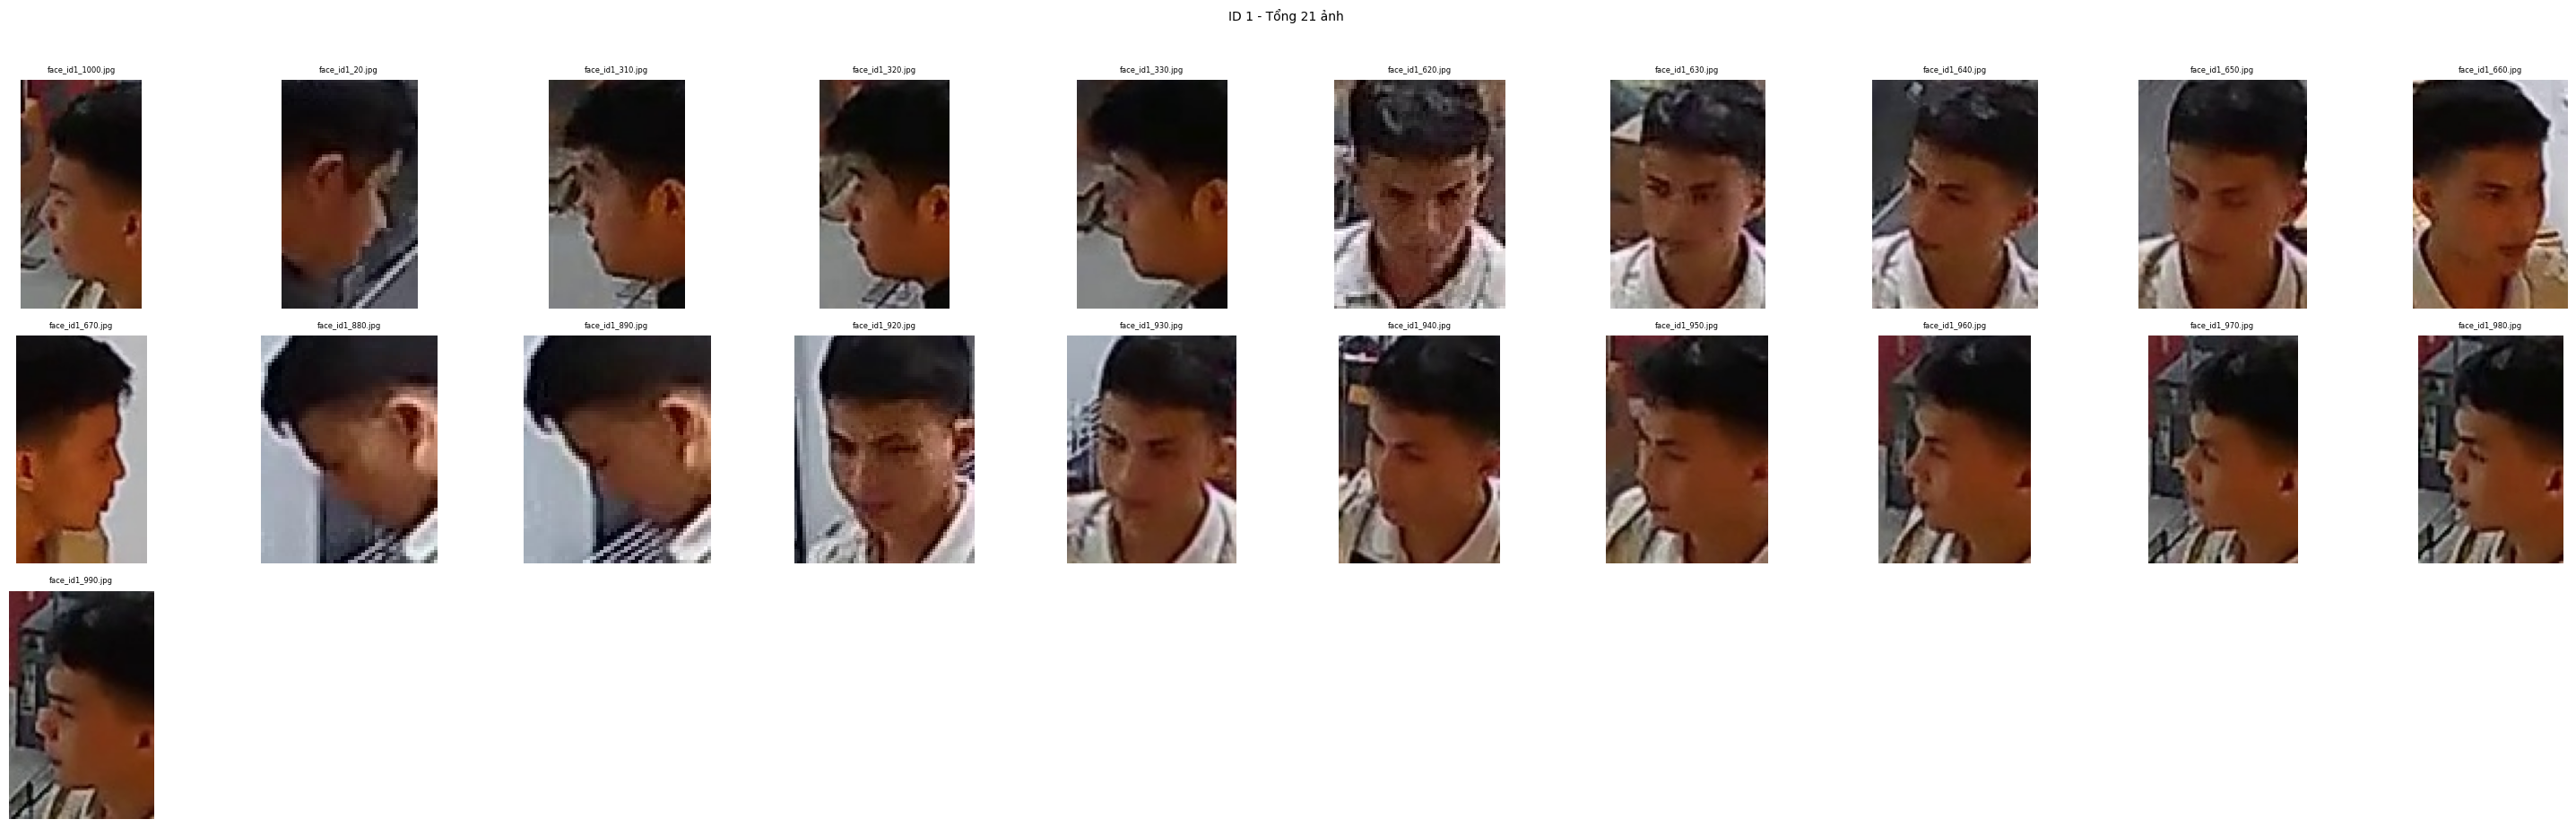

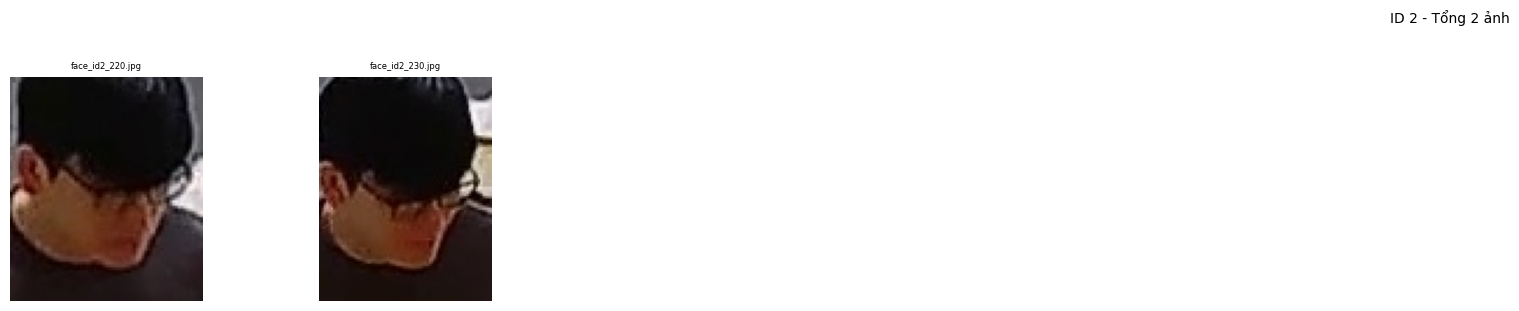

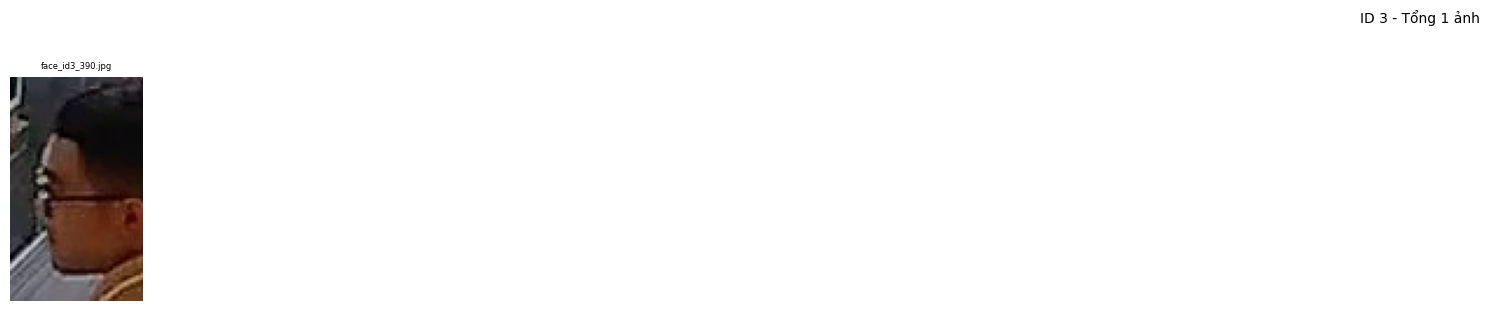

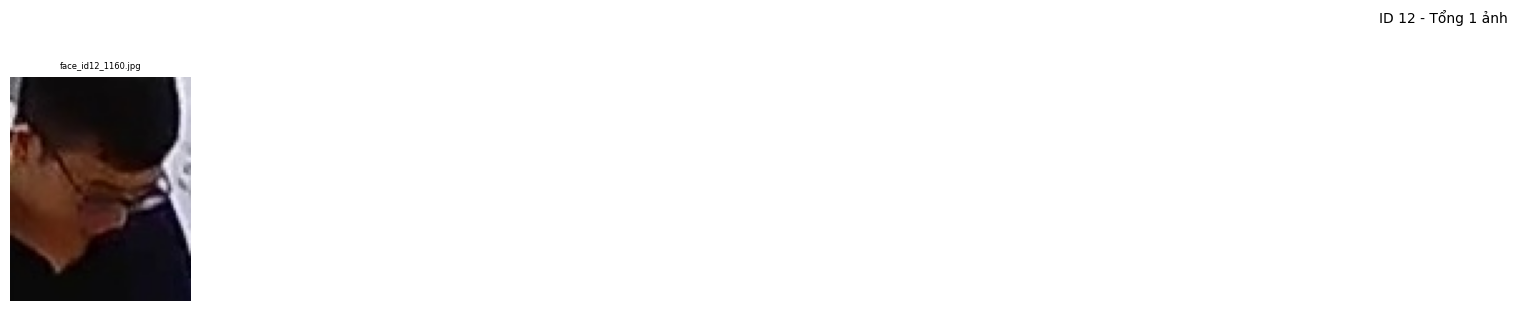

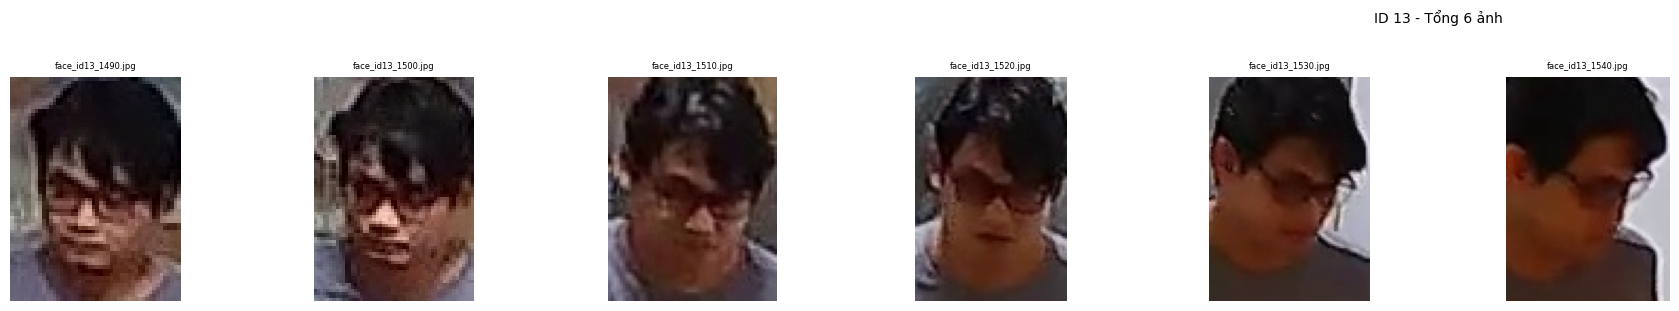

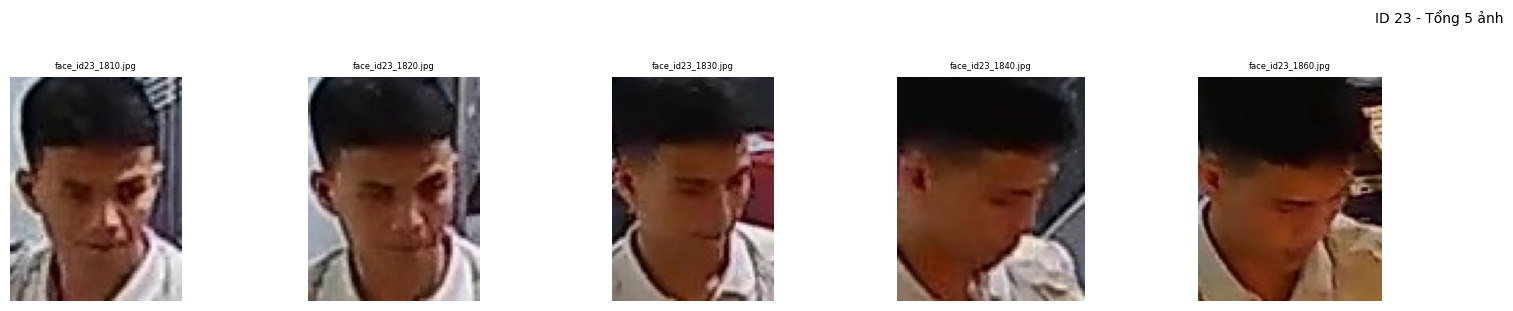

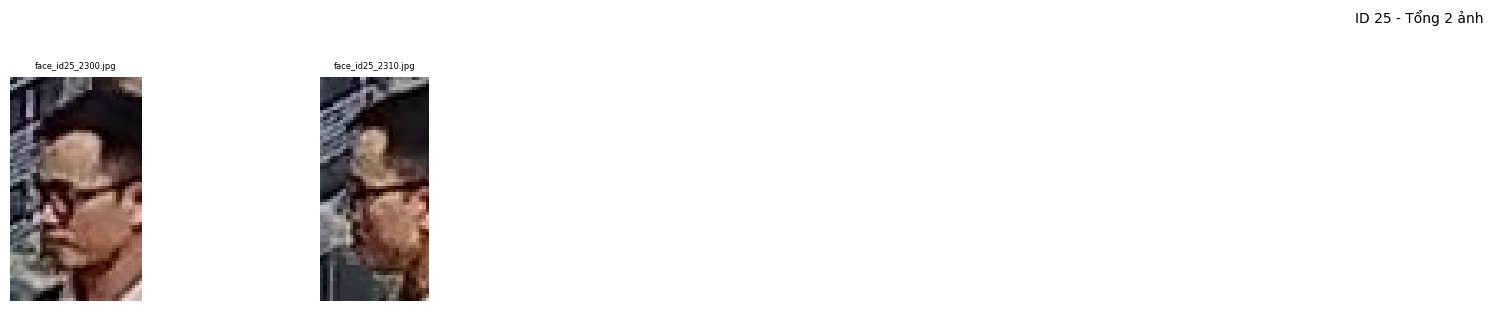

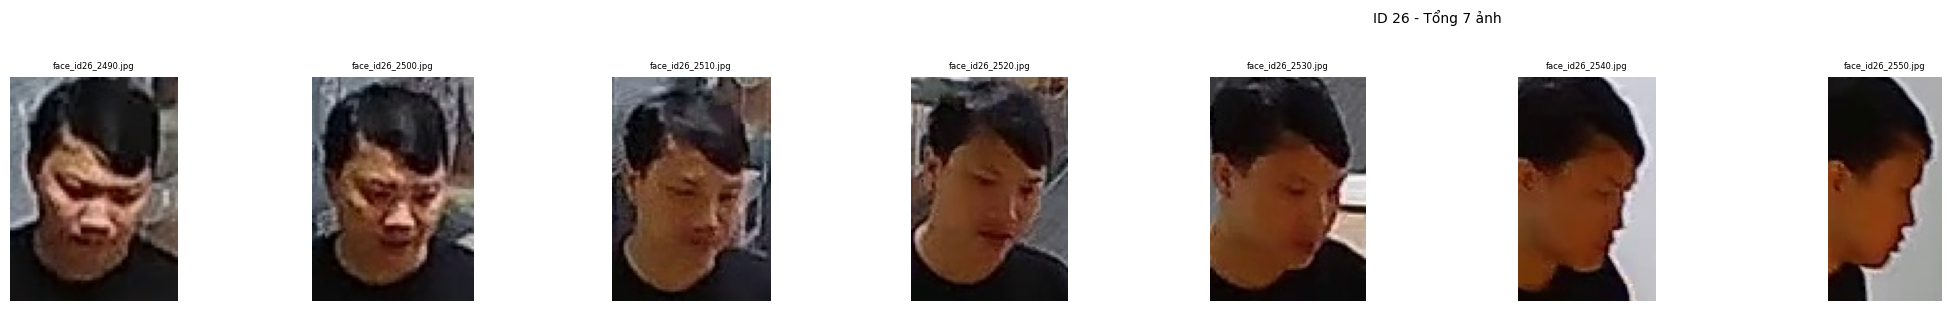

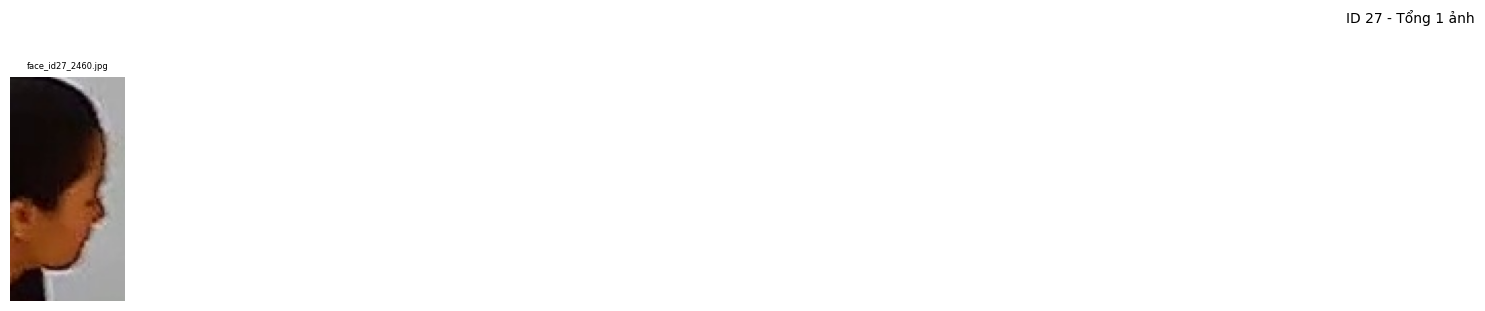

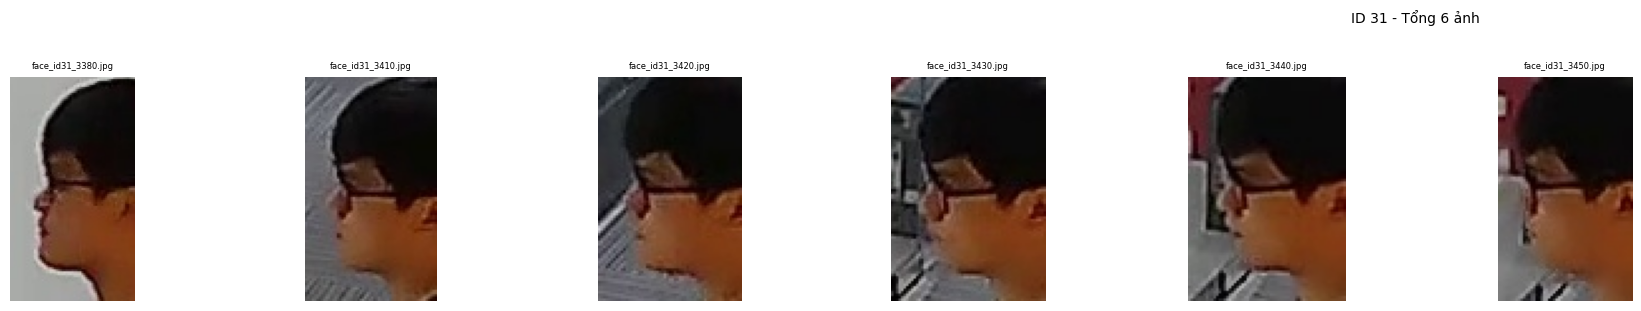

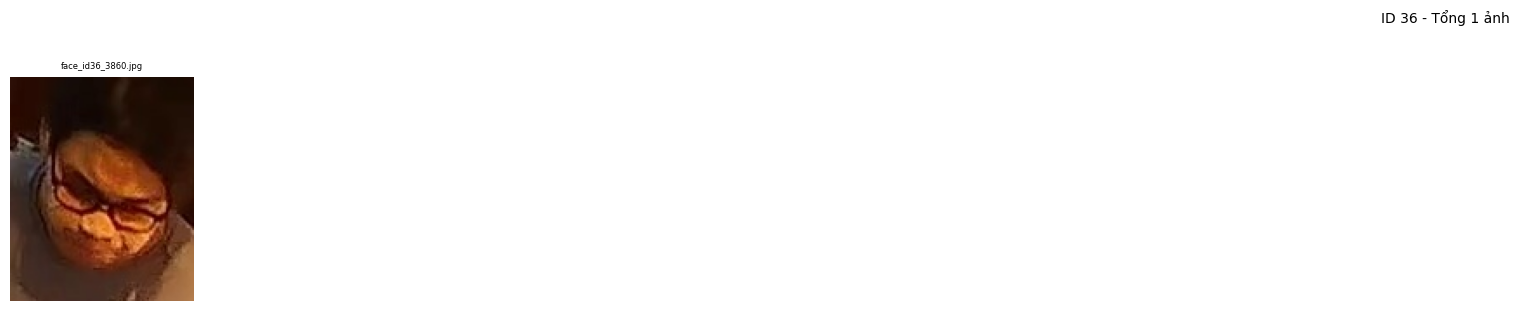

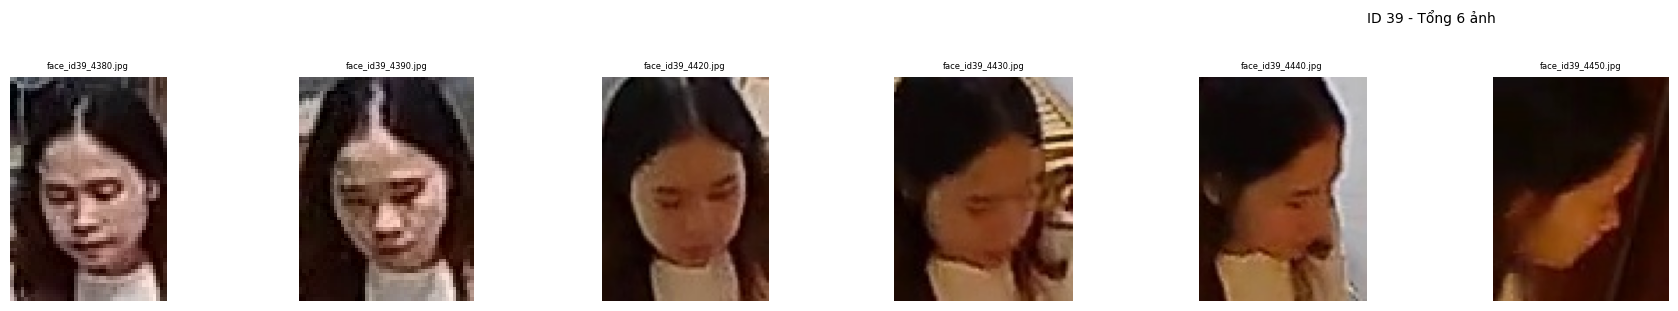

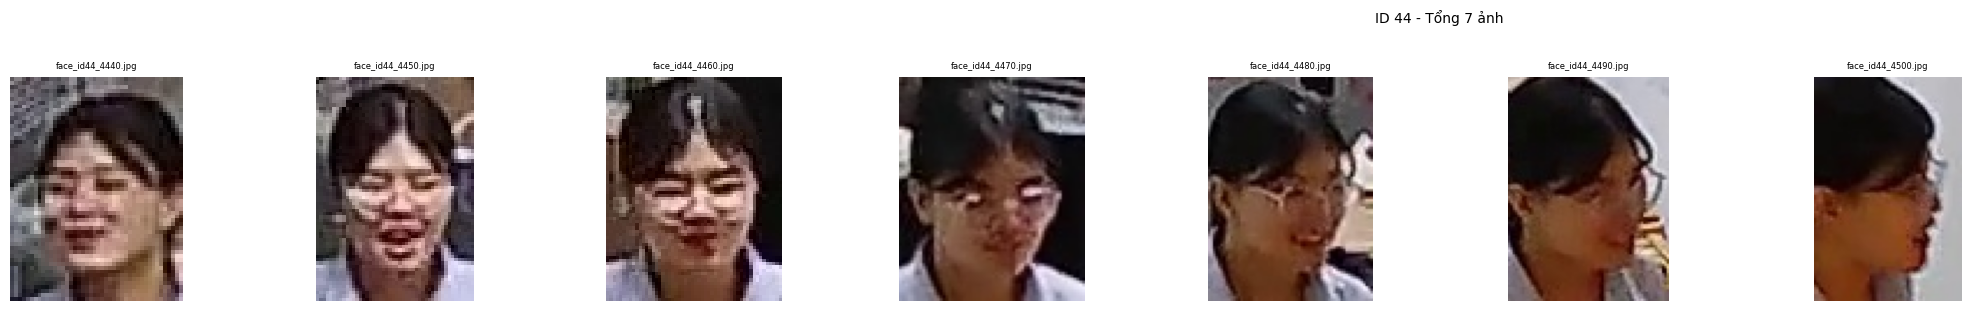

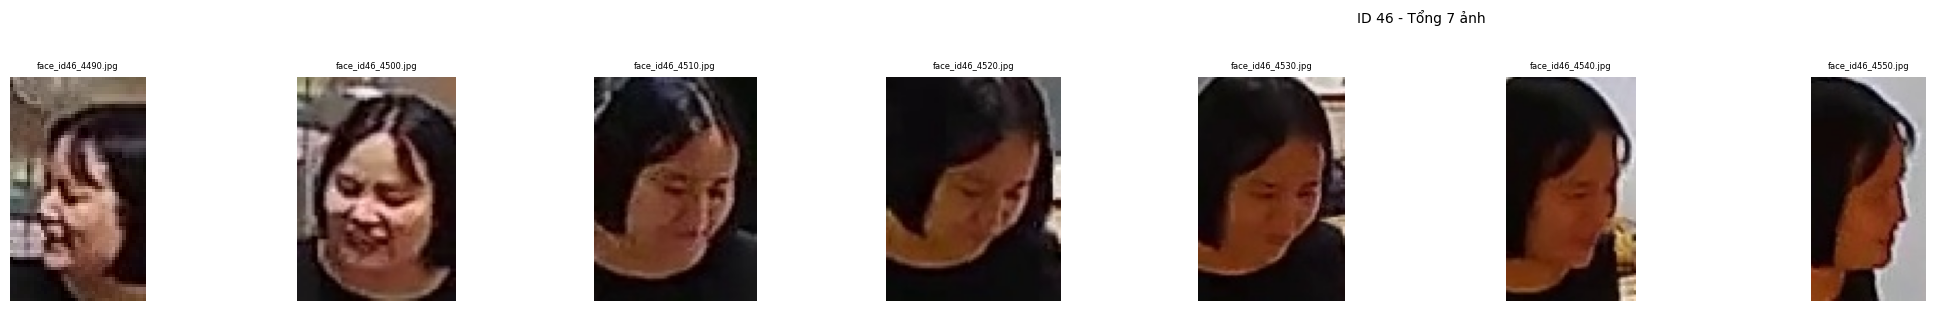

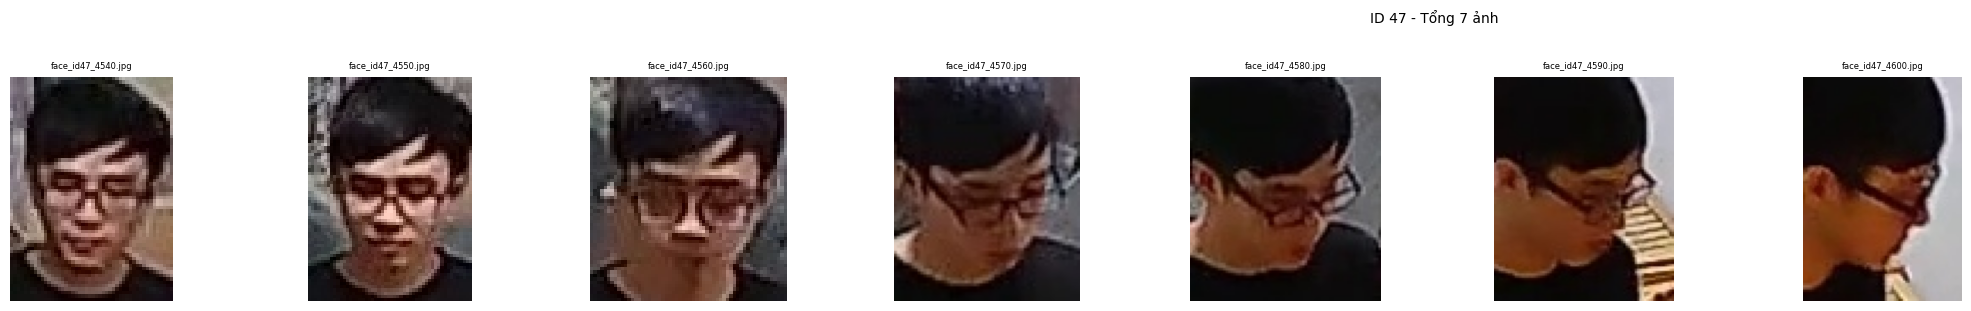

In [33]:
if not groups_roi:
    print("Không tìm thấy ảnh trong thư mục.")
else:
    print(f"Tìm thấy {len(groups_roi)} ID trong thư mục {THIRD_DIR}")

    for tid, files in sorted(groups_roi.items()):
        n_imgs = len(files)
        n_rows = math.ceil(n_imgs / IMAGES_PER_ROW)
        plt.figure(figsize=(3 * IMAGES_PER_ROW, 3 * n_rows))
        for idx, fname in enumerate(files):
            img = cv2.imread(os.path.join(THIRD_DIR, fname))
            if img is None:
                continue

            plt.subplot(n_rows, IMAGES_PER_ROW, idx + 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f"{fname}", fontsize=6)
            plt.axis("off")

        plt.suptitle(f"ID {tid} - Tổng {n_imgs} ảnh", fontsize=10, y=1.02)
        plt.tight_layout()
        plt.show()

### `CLAHE Lighting`

In [ ]:
INPUT_DIR = "face_padding_roi"
OUTPUT_DIR = "face_padding_roi_clahe"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# CLAHE tinh chỉnh nhẹ cho indoor lighting
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

for fname in os.listdir(INPUT_DIR):
    if not fname.lower().endswith((".jpg", ".png", ".jpeg")):
        continue
    img = cv2.imread(os.path.join(INPUT_DIR, fname))
    if img is None:
        continue
    # Chuyển sang không gian LAB (tốt hơn YUV khi xử lý da)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_clahe = clahe.apply(l)

    # Gộp lại và chuyển về BGR
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    blur = cv2.GaussianBlur(img_clahe, (3,3), 0)
    sharp = cv2.addWeighted(img_clahe, 1.2, blur, -0.2, 0)
    cv2.imwrite(os.path.join(OUTPUT_DIR, fname), sharp)

### `Image Enhancement/Restoration`

In [ ]:
import os, cv2
from gfpgan import GFPGANer
from tqdm import tqdm

IN = "face_padding_roi_clahe"
OUT = "face_padding_roi_clahe_restore"
MODEL_PATH = 'weights/GFPGANv1.3.pth'

os.makedirs(OUT, exist_ok = True)
restorer = GFPGANer(
    model_path = MODEL_PATH,
    upscale = 2,
    arch = 'clean',
    channel_multiplier = 2
)

for file in tqdm(sorted(os.listdir(IN))):
    if not file.lower().endswith(".jpg"):
        continue
    img_path = os.path.join(IN, file)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Khong doc duoc file anh {file}")
        continue
    try:
        _, _, restored = restorer.enhance(
            img, has_aligned = False, only_center_face = False, paste_back = True
        )
        out_path = os.path.join(OUT, file)
        cv2.imwrite(out_path, restored)
    except Exception as e:
        print(f"Loi khi xu ly file {file}: {e}")